
SKENARIO FSP: baseline


2026-08-14 08:26:03.177990: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-08-14 08:26:03.178009: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2026-08-14 08:26:03.178016: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.66 GB
2026-08-14 08:26:03.178350: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-14 08:26:03.178597: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


[ref-uuss] /Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/retraining_mcu_q_indonesia/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C data, test n2222 r100.json
[ref-uuss] terpakai: 2222 kejadian | dilewati: 0
[ref-stead] /Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/retraining_mcu_q_indonesia/Benchmark_ STEAD 3C_ test n15275 r100/STEAD data, test n15275 r100.json
[ref-stead] terpakai: 15275 kejadian | dilewati: 0
[uji] /Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/retraining_mcu_q_indonesia/data_indonesia/indonesia_test_data.json
[uji] terpakai: 1032 kejadian | dilewati: 0
[CEK] referensi 17497 | uji 1032 | irisan 0 ✓
[INFO] Menghitung Hyperplane Feature-Space Planes (FSP) dari referensi...
[INFO] Inferensi pada himpunan uji menggunakan FSP...

--- METRIK FSP ---
Accuracy: [0.7383720930232558, 0.7383720930232558]
Accuracy (avg.): 0.7383720930232558
True positive rate: [0.48352713178294576, 0.9932170542635659]
True positive rate (avg.): 0.7383720930232558
True nega

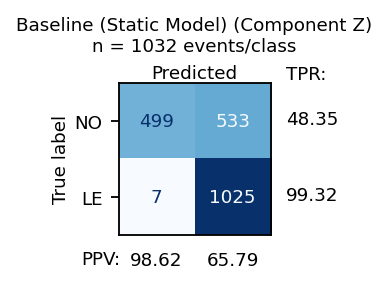

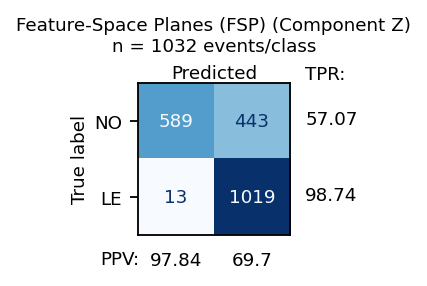

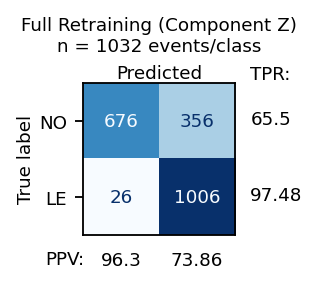

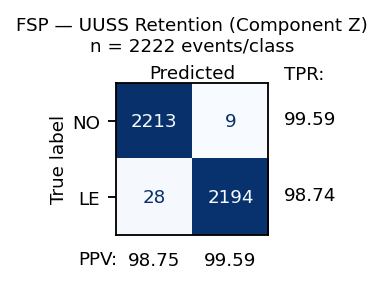

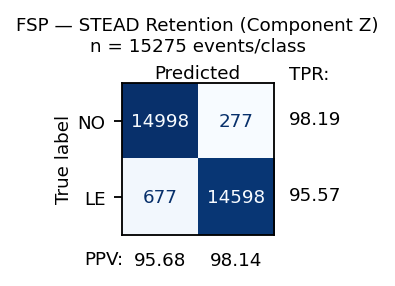

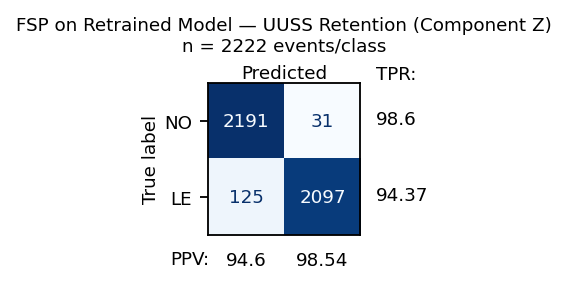

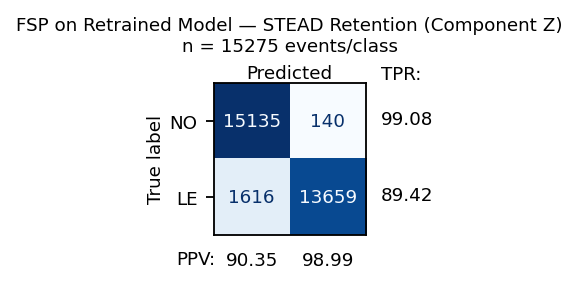

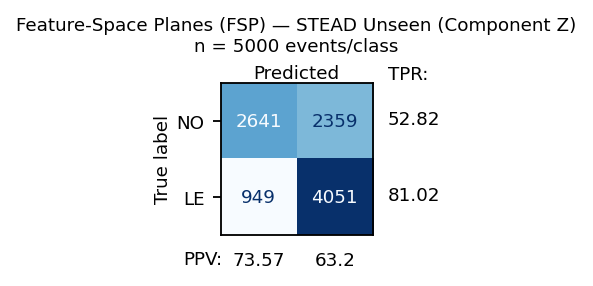

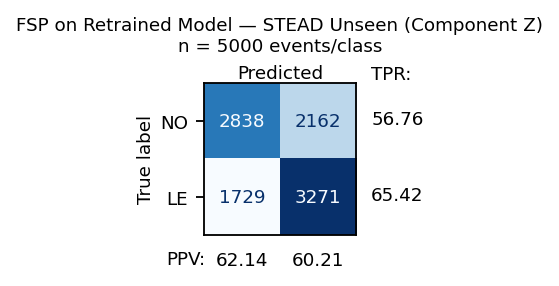

In [1]:
# -*- coding: utf-8 -*-
"""
Evaluasi Feature-Space Planes (FSP) dengan pemisahan latih/uji yang ketat.
Menggantikan KDE Re-Embedding dengan pemisahan hyperplane berbasis centroid laten.
"""

import os
import json
import argparse
import numpy as np
import tensorflow as tf

from Library.utils import (
    latent_codes_1D,
    calc_confusion_metrics,
    plot_confusion,
)

# ==========================================
# KONFIGURASI PATH
# ==========================================
BASE_DATA = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/retraining_mcu_q_indonesia/data_indonesia"
TRAIN_JSON = os.path.join(BASE_DATA, "indonesia_train_data.json")
TEST_JSON = os.path.join(BASE_DATA, "indonesia_test_data.json")

UUSS_JSON = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/retraining_mcu_q_indonesia/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C data, test n2222 r100.json"
STEAD_JSON = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/retraining_mcu_q_indonesia/Benchmark_ STEAD 3C_ test n15275 r100/STEAD data, test n15275 r100.json"
STEAD_UNSEEN_JSON = '/Volumes/Extreme SSD/stream_stead/data_stead/stead_sample_5000/STEAD_5000_3C_20260719_062844.json'

BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/mcquake_ori_file/Code & Figure demo"
MODEL_PRETRAINED = os.path.join(BASE_REP, "Pre-trained model/MCU-Quake 5-20")
MODEL_RETRAINED = "output_models/frozen_extractor_indonesia_Z.keras"

OUTPUT_DIR = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/retraining_mcu_q_indonesia/output_fsp_indo"
INPUT_SIZE = 700
CHANNEL = "Z"
NOISE_CHANNEL = f"{CHANNEL}_noise"

SCENARIOS = {
    "baseline":               (MODEL_PRETRAINED, "source",    TEST_JSON),
    "fsp_reembed":            (MODEL_PRETRAINED, TRAIN_JSON,  TEST_JSON),
    "retrained":              (MODEL_RETRAINED,  TRAIN_JSON,  TEST_JSON),
    "retention_uuss":           (MODEL_PRETRAINED, TRAIN_JSON,  UUSS_JSON),
    "retention_stead":          (MODEL_PRETRAINED, TRAIN_JSON,  STEAD_JSON),
    "retention_uuss_retrain":   (MODEL_RETRAINED,  TRAIN_JSON,  UUSS_JSON),
    "retention_stead_retrain":  (MODEL_RETRAINED,  TRAIN_JSON,  STEAD_JSON),
    "retention_stead_unseen":         (MODEL_PRETRAINED, TRAIN_JSON,  STEAD_UNSEEN_JSON),
    "retention_stead_unseen_retrain": (MODEL_RETRAINED,  TRAIN_JSON,  STEAD_UNSEEN_JSON),
}

# Judul gambar yang rapi untuk publikasi (bahasa Inggris, tanpa nama variabel
# mentah) — konsisten dengan SCENARIO_DISPLAY_TITLES di evaluate_kde_re_embedding_all.py.
SCENARIO_DISPLAY_TITLES = {
    "baseline": "Baseline (Static Model)",
    "fsp_reembed": "Feature-Space Planes (FSP)",
    "retrained": "Full Retraining",
    "retention_uuss": "FSP — UUSS Retention",
    "retention_stead": "FSP — STEAD Retention",
    "retention_uuss_retrain": "FSP on Retrained Model — UUSS Retention",
    "retention_stead_retrain": "FSP on Retrained Model — STEAD Retention",
    "retention_stead_unseen": "Feature-Space Planes (FSP) — STEAD Unseen",
    "retention_stead_unseen_retrain": "FSP on Retrained Model — STEAD Unseen",
}

# ==========================================
# UTILITAS JSON AMAN
# ==========================================
class NpEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super(NpEncoder, self).default(obj)

# ==========================================
# EKSTRAKSI EMBEDDING
# ==========================================
def build_embeddings(json_path, model, label=""):
    if not os.path.exists(json_path):
        raise FileNotFoundError(f"Berkas tidak ditemukan: {json_path}")
    with open(json_path, "r") as f:
        data = json.load(f)

    out = {"keys": [], "noise": [], "le": []}
    skipped = []

    for key, rec in data.items():
        try:
            sig_le = np.array(rec[CHANNEL][:INPUT_SIZE])
            sig_no = np.array(rec[NOISE_CHANNEL][-INPUT_SIZE:])
            if len(sig_le) != INPUT_SIZE or len(sig_no) != INPUT_SIZE:
                raise ValueError(f"panjang jendela {len(sig_le)}/{len(sig_no)}")
            
            emb_le = np.array(latent_codes_1D(sig_le, model)).flatten()
            emb_no = np.array(latent_codes_1D(sig_no, model)).flatten()
            
            out["le"].append(emb_le)
            out["noise"].append(emb_no)
            out["keys"].append(key)
        except Exception as e:
            skipped.append((key, str(e)))

    print(f"[{label}] {json_path}")
    print(f"[{label}] terpakai: {len(out['keys'])} kejadian | dilewati: {len(skipped)}")
    return out, skipped

def assert_disjoint(ref, test):
    overlap = set(ref["keys"]) & set(test["keys"])
    if overlap:
        raise RuntimeError(f"KEBOCORAN DATA: {len(overlap)} event_id muncul ganda.")
    print(f"[CEK] referensi {len(ref['keys'])} | uji {len(test['keys'])} | irisan 0 ✓")

# ==========================================
# EVALUASI SATU SKENARIO (PURE FSP)
# ==========================================
def run_scenario(name):
    model_path, ref_source, test_path = SCENARIOS[name]

    print("\n" + "=" * 70)
    print(f"SKENARIO FSP: {name}")
    print("=" * 70)

    if ref_source != "source" and not os.path.exists(ref_source):
        return None, None
    if not os.path.exists(test_path):
        return None, None
    if not os.path.exists(model_path):
        return None, None

    full_model = tf.keras.models.load_model(model_path, compile=False)
    
    latent_layer = None
    for layer in full_model.layers:
        if hasattr(layer, 'output_shape') and isinstance(layer.output_shape, tuple):
            if layer.output_shape[-1] == 32:
                latent_layer = layer.output
                break
                
    if latent_layer is None:
        latent_layer = full_model.layers[-2].output

    model = tf.keras.Model(inputs=full_model.inputs, outputs=latent_layer)

    if ref_source == "source":
        try:
            ref_u, _ = build_embeddings(UUSS_JSON, model, "ref-uuss")
            ref_s, _ = build_embeddings(STEAD_JSON, model, "ref-stead")
            ref = {
                "keys": ref_u["keys"] + ref_s["keys"],
                "noise": ref_u["noise"] + ref_s["noise"],
                "le": ref_u["le"] + ref_s["le"],
            }
        except FileNotFoundError:
            return None, None
    else:
        ref, _ = build_embeddings(ref_source, model, "referensi")

    test, skipped = build_embeddings(test_path, model, "uji")
    if len(ref["keys"]) == 0 or len(test["keys"]) == 0:
        return None, None

    assert_disjoint(ref, test)

    print("[INFO] Menghitung Hyperplane Feature-Space Planes (FSP) dari referensi...")
    
    # 1. Hitung Centroid dari himpunan referensi
    centroid_noise = np.mean(np.array(ref["noise"]), axis=0)
    centroid_signal = np.mean(np.array(ref["le"]), axis=0)

    # 2. Tentukan normal vector dan titik tengah (midpoint) hyperplane pemisah
    normal_vector = centroid_signal - centroid_noise
    midpoint = (centroid_signal + centroid_noise) / 2.0

    # 3. Fungsi prediksi FSP murni berbasis proyeksi dot product
    def predict_pure_fsp(features):
        projections = np.dot(features - midpoint, normal_vector)
        return (projections >= 0).astype(int)

    print("[INFO] Inferensi pada himpunan uji menggunakan FSP...")
    true_labels, pred_labels = [], []
    for cls, gt in (("le", 1), ("noise", 0)):
        for emb in test[cls]:
            flat_emb = np.array(emb).flatten()
            pred = int(predict_pure_fsp(flat_emb))
            
            true_labels.append(gt)
            pred_labels.append(pred)

    print("\n--- METRIK FSP ---")
    cnf, metrics = calc_confusion_metrics(true_labels, pred_labels)

    os.makedirs(OUTPUT_DIR, exist_ok=True)
    stem = os.path.join(OUTPUT_DIR, f"{name}_{CHANNEL}_fsp")

    with open(f"{stem}_metrics.json", "w") as f:
        json.dump(
            {
                "skenario": name,
                "metode": "Pure Feature-Space Planes (FSP)",
                "model": model_path,
                "sumber_referensi": ref_source,
                "berkas_uji": test_path,
                "n_referensi": len(ref["keys"]),
                "n_uji": len(test["keys"]),
                "dimensi_laten": int(np.asarray(test["le"][0]).shape[-1]),
                "confusion_matrix": cnf,
                "metrics": metrics,
            },
            f, indent=2, cls=NpEncoder
        )

    display_name = SCENARIO_DISPLAY_TITLES.get(name, name)
    fig = plot_confusion(
        title=f"{display_name} (Component {CHANNEL})\nn = {len(test['keys'])} events/class",
        true_labels=["NO", "LE"],
        matrix=cnf,
        metrics=metrics,
    )
    fig.savefig(f"{stem}_confusion.png", bbox_inches="tight", dpi=300)
    print(f"\n✅ Skenario FSP {name} selesai — Tersimpan: {stem}_confusion.png")

    return cnf, metrics

# ==========================================
# EKSEKUSI
# ==========================================
def run_all(skenario="all"):
    targets = list(SCENARIOS) if skenario == "all" else [skenario]
    hasil = {}
    for s in targets:
        cnf, met = run_scenario(s)
        if cnf is not None:
            hasil[s] = (cnf, met)

    if hasil:
        print("\n" + "=" * 70)
        print("RINGKASAN FSP (TNR / Recall / Presisi kelas LE, dalam persen)")
        print("=" * 70)
        print(f"{'skenario':26s} {'TNR':>7s} {'Recall':>8s} {'Presisi':>9s} {'FP':>7s} {'FN':>7s}")
        for s, (cnf, met) in hasil.items():
            tnr = met["True negative rate"][0] * 100
            rec = met["True positive rate"][1] * 100
            ppv = met["Positive predictive value"][1] * 100
            fp = int(cnf[0][1])
            fn = int(cnf[1][0])
            print(f"{s:26s} {tnr:7.2f} {rec:8.2f} {ppv:9.2f} {fp:7d} {fn:7d}")
    return hasil

if __name__ == "__main__":
    import sys
    if "ipykernel" in sys.modules:
        run_all("all")
    else:
        ap = argparse.ArgumentParser()
        ap.add_argument("skenario", nargs="?", default="all", choices=list(SCENARIOS) + ["all"])
        run_all(ap.parse_args().skenario)
